# Loan Approval Analysis

## Introduction
This Project Analyzes a dataset of 45,000 Loan applications to understand patterns in loan approvals.It includes data cleaning,exploratory data analysis(EDA) and visulizations of key factors such as age,income,education,employment experience and income-to-loan-ratio.Insights from this analysis help identify trends in loan approval rates and applicant characteristics,providing a clear view of lending patterns.

## 1.Importing Required Librar

In [1]:
import pandas as pd #for data handling
import numpy as np #for numerical operations
import matplotlib.pyplot as plt # for plotting 
import seaborn as sns # for statistical visulization

## 2.Loading and Exploring the Dataset

In [2]:
#Load dataset
df=pd.read_csv('loan_data.csv')

#Rename column
df.rename(columns={'loan_amnt':'loan_amount'},inplace=True)

#View first 5 rows
print(df.head())

#View last 5 rows
print(df.tail())

#Dataset info
df.info()

#Descriptive statistics for numerical columns
df.describe()

   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amount loan_intent  loan_int_rate  \
0                  RENT      35000.0    PERSONAL          16.02   
1                   OWN       1000.0   EDUCATION          11.14   
2              MORTGAGE       5500.0     MEDICAL          12.87   
3                  RENT      35000.0     MEDICAL          15.23   
4                  RENT      35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.0    

,person_age,person_income,person_emp_exp,loan_amount,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## 3.Data Cleaning

In [3]:
#check missing values
print(df.isnull().sum())

#check duplicates
print(df.duplicated().sum())

#clip extreme income values to reduce skewness
df['person_income'] = df['person_income'].clip(upper=1000000)

#Remove unrealistic ages
df = df[df['person_age'] <= 100]

#Convert age to integer
df['person_age'] = df['person_age'].astype(int)

#Convert categorical columns to category dtype
cat_cols = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
for col in cat_cols:
    df[col] = df[col].astype('category')
#Verify dtypes   
print(df.dtypes)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amount                       0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
0
person_age                           int32
person_gender                     category
person_education                  category
person_income                      float64
person_emp_exp                       int64
person_home_ownership             category
loan_amount                        float64
loan_intent                       category
loan_int_rate                      float64
loan_percent_income                float64
cb_person_cred_hist_length         float64
credit_s

**Interpretation** :
- NO **Missing** or **Duplicate** values were found in the dataset.Unrealistic ages(>100) were removed and income values were capped at 1,000,000 to reduce skewness.categorical columns were converted to **category** type for better memory usage and analysis efficiency.

## 4.Numeric Columns Overview & Outlier Check

In [4]:
numeric_cols = ['person_income', 'loan_amount', 'loan_int_rate', 
                'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
for col in numeric_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

person_income: min=8000.0, max=1000000.0
loan_amount: min=500.0, max=35000.0
loan_int_rate: min=5.42, max=20.0
loan_percent_income: min=0.0, max=0.66
cb_person_cred_hist_length: min=2.0, max=30.0
credit_score: min=390, max=784


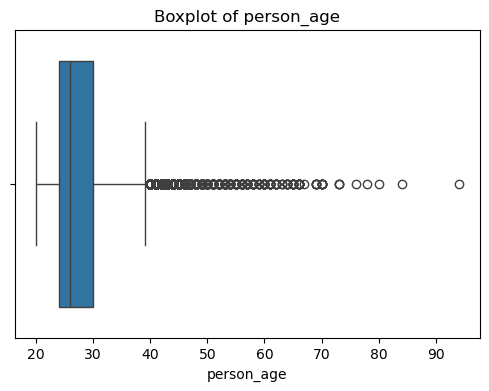

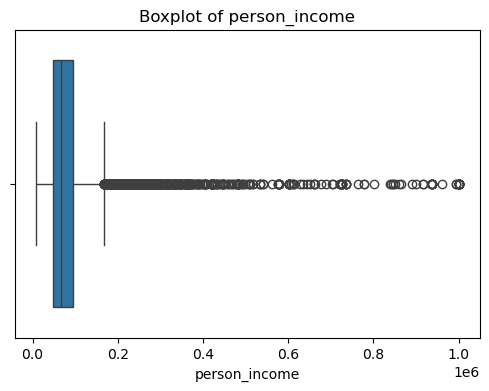

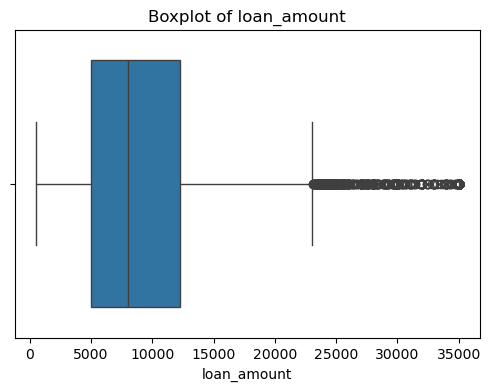

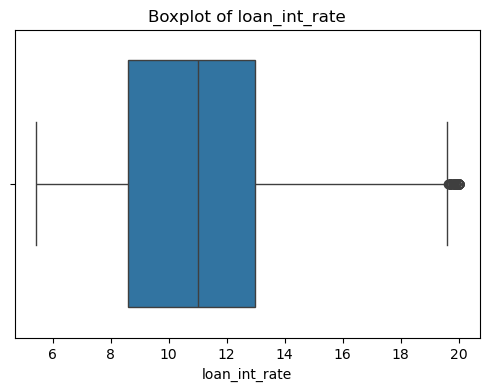

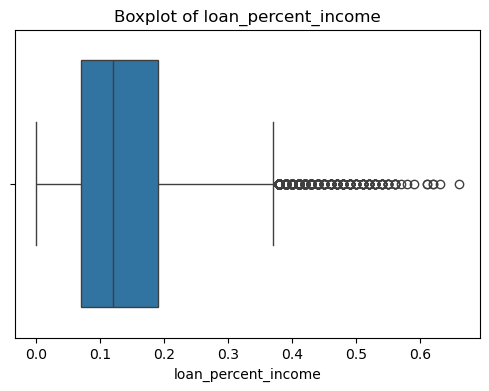

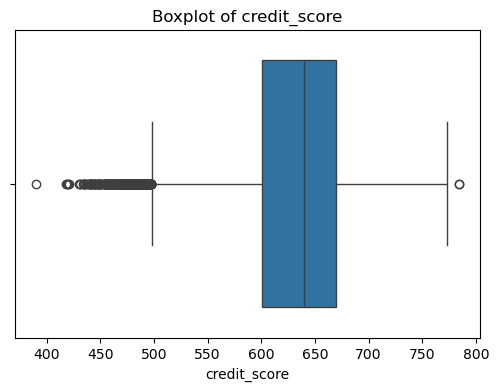

In [5]:
num_cols = ['person_age', 'person_income', 'loan_amount', 'loan_int_rate', 'loan_percent_income', 'credit_score']
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Box plots were used to examine the range and spread of numerical variables and idnetify potential outliers in the dataset.

## 5.Feature Engineering

We created new features to better understand patterns in loan approval:
- **income_to_loan_ratio**:Ratio of applicants income to requested loan amount.
- **age_group**:Age categories created by binning person_age into 18-30,31-40,41-50 etc.
- **emp_exp_group**:Groups applicants based on employment experience.
- **income_to_loan_group**:Binned income_to_loan_ratio.
- **person_income_log**:Log transformation of income to reduce skewness.

In [6]:
#Income to loan Ratio:
df['income_to_loan_ratio'] = df['person_income'] / df['loan_amount']

#Agre Groups:
# Define bins and labels
bins = [20, 30, 40, 50, 60, 100]  # age ranges
labels = ['21-30','31-40','41-50','51-60','60+']
df['age_group'] = pd.cut(df['person_age'], bins=bins, labels=labels)

#Employment Experience Groups:
bins = [0, 2, 5, 10, df['person_emp_exp'].max()]
labels = ['0-2', '3-5', '6-10', '10+']
df['emp_exp_group'] = pd.cut(df['person_emp_exp'], bins=bins, labels=labels, include_lowest=True)

#Income-to-Loan Groups:
# Define bins and labels
bins = [0, 1, 2, 3, 10]
labels = ['0-1','1-2','2-3','3+']

# Step 1: Create income_to_loan_group
df['income_to_loan_group'] = pd.cut(
    df['income_to_loan_ratio'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Step 2: Handle missing or out-of-range values
df['income_to_loan_group'] = df['income_to_loan_group'].cat.add_categories('Unknown').fillna('Unknown')

# Step 3: Ensure all bins are categorical (order matters if needed)
df['income_to_loan_group'] = pd.Categorical(
    df['income_to_loan_group'], 
    categories=labels + ['Unknown'], 
    ordered=True
)

#Log-Transformed Income:
# log1p = log(1 + x), safe even if income = 0
df['person_income_log'] = np.log1p(df['person_income'])

# Show outputs of new columns
df[['person_income','loan_amount','income_to_loan_ratio','person_age','age_group',
    'person_emp_exp','emp_exp_group','income_to_loan_group','person_income_log']].head()

,person_income,loan_amount,income_to_loan_ratio,person_age,age_group,person_emp_exp,emp_exp_group,income_to_loan_group,person_income_log
0,71948.0,35000.0,2.055657,22,21-30,0,0-2,2-3,11.183713
1,12282.0,1000.0,12.282000,21,21-30,0,0-2,Unknown,9.415971
2,12438.0,5500.0,2.261455,25,21-30,3,3-5,2-3,9.428592
3,79753.0,35000.0,2.278657,23,21-30,0,0-2,2-3,11.286702
4,66135.0,35000.0,1.889571,24,21-30,1,0-2,1-2,11.099469


### Log Transformation of Income(Histogram)

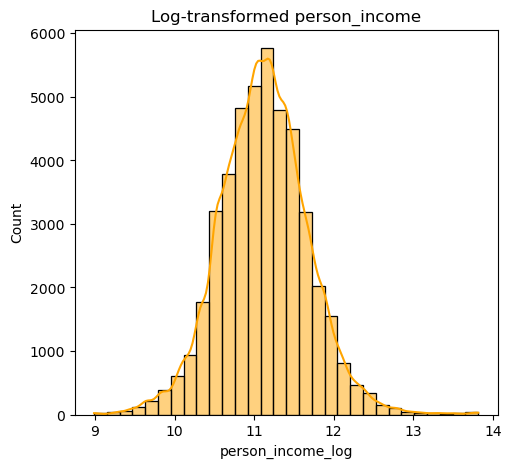

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Log-transformed income
plt.subplot(1,2,2)
sns.histplot(df['person_income_log'], kde=True, bins=30, color='orange')
plt.title('Log-transformed person_income')
plt.show()

**Interpretation**:
- Log transformation reduced skew in income distribution.
- Makes loan approval patterns easier to observe.
- Prevents extreme values from dominating the analysis.

## 6.Exploratory Data Analysis (EDA) & KPI Calculations

### 1.Overall Loan Approval Rate

In [8]:
# Calculate overall approval rate
approval_rate = df['loan_status'].mean() * 100
rejection_rate = 100 - approval_rate

print(f"Overall Loan Approval Rate: {approval_rate:.2f}%")
print(f"Overall Loan Rejection Rate: {rejection_rate:.2f}%")

Overall Loan Approval Rate: 22.23%
Overall Loan Rejection Rate: 77.77%


### 2.Loan Approval  by Gender

In [9]:
#Approval rate by gender
approval_by_gender = df.groupby('person_gender',observed=True)['loan_status'].mean() * 100
print(approval_by_gender)

person_gender
female    22.250335
male      22.205669
Name: loan_status, dtype: float64


### 3.Loan Approval by Age Group

In [11]:
#Approval Rate by Age Group:
approval_by_age_group = df.groupby('age_group',observed=True)['loan_status'].mean()*100
print(approval_by_age_group)

age_group
21-30    22.625211
31-40    20.817165
41-50    20.648577
51-60    26.000000
60+      25.352113
Name: loan_status, dtype: float64


### 4.Loan Approval by Income-to-Loan Group

In [10]:
#Calculate Approval Rate by Income-to-Lon Ratio group
approval_by_ratio = df.groupby('income_to_loan_group',observed=True)['loan_status'].mean() * 100
print(approval_by_ratio)

income_to_loan_group
1-2        70.000000
2-3        75.344353
3+         26.310484
Unknown    11.747414
Name: loan_status, dtype: float64


### 5.Loan Approval by Education Level 

In [11]:
#Calculate Approval Rate by Education level
approval_by_education = df.groupby('person_education',observed=True)['loan_status'].mean() * 100
print(approval_by_education)

person_education
Associate      22.035590
Bachelor       22.529113
Doctorate      22.866345
High School    22.314119
Master         21.762178
Name: loan_status, dtype: float64


### 6.Loan Approval by Employment Experience

In [12]:
#calculate Approval Rate by Employment Experience Group
approval_by_exp= df.groupby('emp_exp_group',observed=True)['loan_status'].mean() * 100
print(approval_by_exp)

emp_exp_group
0-2     23.489668
3-5     21.682351
6-10    21.742246
10+     20.513548
Name: loan_status, dtype: float64


### 7.Loan Approval by Home Ownership

In [13]:
#Calculate Approval Rate by Home Ownership
approval_by_home = df.groupby('person_home_ownership',observed=True)['loan_status'].mean() * 100
print(approval_by_home)

person_home_ownership
MORTGAGE    11.598593
OTHER       33.333333
OWN          7.522874
RENT        32.401877
Name: loan_status, dtype: float64


### 8.loan Approval by Previous Loan Defaults

In [14]:
#count of Approved vs rejected Applications by previous loan Defaults
approval_count_by_default=df.groupby('previous_loan_defaults_on_file',observed=True)['loan_status'].value_counts()
print(approval_count_by_default)

previous_loan_defaults_on_file  loan_status
No                              0              12137
                                1              10000
Yes                             0              22856
Name: count, dtype: int64


In [15]:
#Approval Percentage by Previous Loan Defaults and Income-to-Loab Group
approval_crosstab_by_default_income=pd.crosstab([df['previous_loan_defaults_on_file'],df['income_to_loan_group']],df['loan_status'],normalize='index')*100
print(approval_crosstab_by_default_income)

loan_status                                                   0          1
previous_loan_defaults_on_file income_to_loan_group                       
No                             1-2                    10.638298  89.361702
                               2-3                     9.958848  90.041152
                               3+                     49.236984  50.763016
                               Unknown                72.319169  27.680831
Yes                            1-2                   100.000000   0.000000
                               2-3                   100.000000   0.000000
                               3+                    100.000000   0.000000
                               Unknown               100.000000   0.000000


### 9.Loan Intent Analysis

#### Loan Approval Rate by Loan Intent

In [16]:
#calculate Loan Approval Rate by Loan Intent
approval_by_intent = df.groupby('loan_intent', observed=True)['loan_status'].mean().reset_index()
approval_by_intent['ApprovalRate'] = (approval_by_intent['loan_status'] * 100).round(2)

# Sort descending
approval_by_intent = approval_by_intent.sort_values(by='ApprovalRate', ascending=False)

print(approval_by_intent[['loan_intent', 'ApprovalRate']])

         loan_intent  ApprovalRate
0  DEBTCONSOLIDATION         30.27
3            MEDICAL         27.82
2    HOMEIMPROVEMENT         26.30
4           PERSONAL         20.14
1          EDUCATION         16.96
5            VENTURE         14.43


#### Average Loan Amount by Loan intent

In [17]:
avg_loan_by_intent = df.groupby('loan_intent', observed=True)['loan_amount'].mean().reset_index()
avg_loan_by_intent.rename(columns={'loan_amount': 'Avg_loan_amount'}, inplace=True)

# Round and sort descending
avg_loan_by_intent['Avg_loan_amount'] = avg_loan_by_intent['Avg_loan_amount'].round(2)
avg_loan_by_intent = avg_loan_by_intent.sort_values(by='Avg_loan_amount', ascending=False)

print(avg_loan_by_intent)

         loan_intent  Avg_loan_amount
2    HOMEIMPROVEMENT         10419.19
5            VENTURE          9659.39
4           PERSONAL          9604.53
0  DEBTCONSOLIDATION          9548.33
1          EDUCATION          9506.60
3            MEDICAL          9137.96


### 10.Median Loan & Income by Home Ownership

In [19]:
df.groupby('person_home_ownership',observed=True)[['loan_amount','person_income']].median()

,loan_amount,person_income
person_home_ownership,,
MORTGAGE,9600.0,85123.0
OTHER,10000.0,72093.0
OWN,7500.0,55004.0
RENT,7500.0,56947.5


**Interpretation**:
- Applicants with **Mortgages** have the highest income and borrow slightly more.
- Those who **Rent** or **Own** borrow less, showing loan amounts align with financial capacity.

### 11.Median Loan & Income by Employment Experience

In [19]:
df.groupby('emp_exp_group',observed=True)[['loan_amount', 'person_income']].median()

,loan_amount,person_income
emp_exp_group,,
0-2,8000.0,63239.0
3-5,8000.0,67375.5
6-10,8148.0,72662.0
10+,8400.0,72868.0


**Interpretation**:
- Loan Amounts and Income grow slightly with Experience,highest for those with 10+ years.

### 12.Income-to-Loan Ratio Crosstab

In [32]:
pd.crosstab(df['emp_exp_group'], df['income_to_loan_group'], values=df['loan_status']*100, aggfunc='mean')

income_to_loan_group,0-1,1-2,2-3,3+
emp_exp_group,,,,
0-2,11.817908,75.862069,78.861789,27.482591
3-5,11.755989,50.000000,72.168285,25.694904
6-10,12.177756,70.588235,72.413793,25.839552
10+,10.978520,100.000000,74.162679,24.763124


**Interpretation**:
- Begiiners (0-2yrs) borrow highest in the 2-3 income group(79%),while highly experinced borrowes(10+yrs) borrow most in lowest income group(100%).
- In general,low-income groups borrow closer to thier income,while high-income groups bprrow a smaller percentage.

## 6.Data Visulizations

### Overall Loan Approval Rate(Pie Chart)

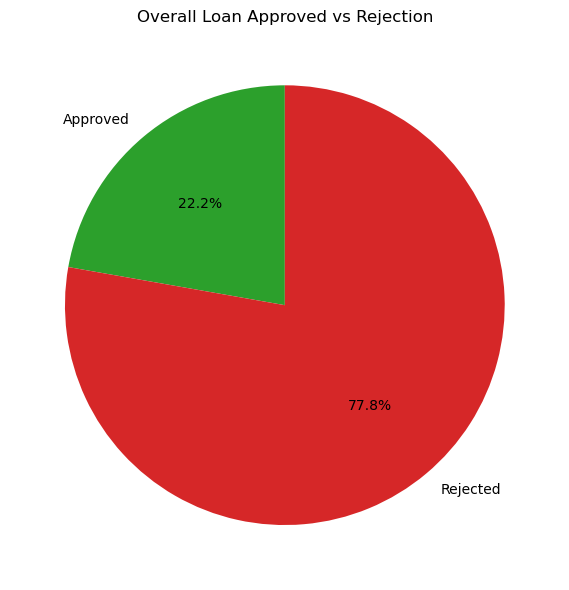

In [20]:
#Create figure for the pie chart
plt.figure(figsize=(6,6))

#Plot pie chart shoing overall approved vs rejected
plt.pie([approval_rate, rejection_rate], 
#category labels        
        labels=['Approved', 'Rejected'], 
#display percentage values        
        autopct='%1.1f%%', 
#green = approved, red = rejected        
        colors=['#2ca02c','#d62728'], 
#rotate chart for better view     
        startangle=90)

#Add chart title
plt.title('Overall Loan Approved vs Rejection')

# Adjust layout
plt.tight_layout()

#Save the chart for report/dashboard usage
plt.savefig("kpi1_Overall Loan Approved vs Rejection.png", dpi=300, bbox_inches='tight')

#Display the chart
plt.show()

**Interpretation**:
- Only **22.23** % of applicants were approved for a loan, while **77.77** % were rejected.
- This shows that the bank follows strict screening criteria, approving loans for a small share of applicants with strong financial profiles.

### Loan Approval by Gender(Pie Chart)

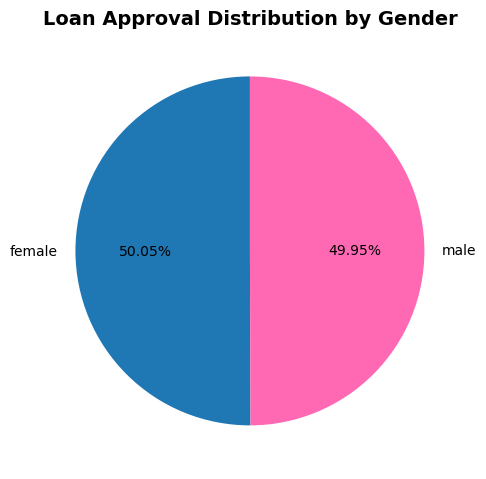

In [22]:
#Create figure for gender approval distribution
plt.figure(figsize=(5,5))

#Plot pie chart for approval rate by gender
plt.pie(
    approval_by_gender.values,
    labels=approval_by_gender.index,
#Show percentages    
    autopct='%1.2f%%',
#Male=blue,Female=pink    
    colors=['#1f77b4', '#FF69B4'],
    startangle=90
)

#Add chart title
plt.title('Loan Approval Distribution by Gender', fontsize=14, fontweight='bold')
#Adjust layout
plt.tight_layout()
#Save the chart
plt.savefig("kpi2_gender.png", dpi=300, bbox_inches='tight')
#Display chart
plt.show()

**Interpretation**:
- Loan approval rates are alomst identical for both genders,**22.21** for **Males** and **22.25** for **Females**.
- This suggests that the loan approval process is gender-neutral in this dataset, with no noticeable bias favoring one gender over the other.

### Loan Approval by Age Group(Bar Chart)

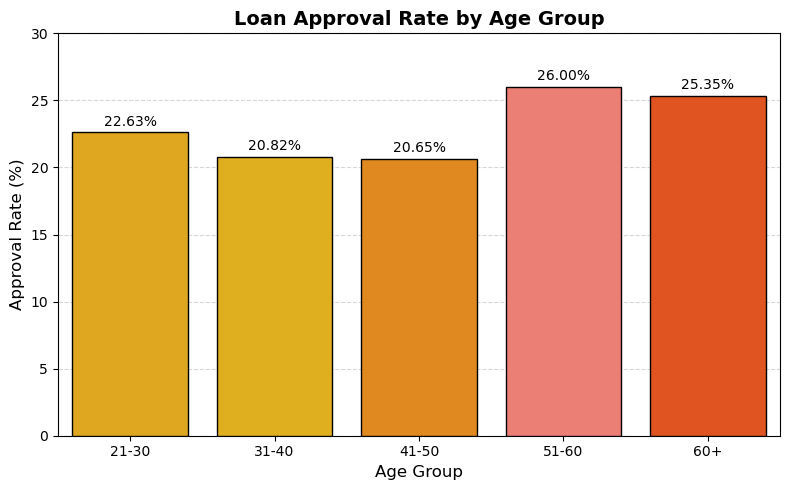

In [23]:
# Create figure for age group approval chart
plt.figure(figsize=(8,5))

# Define color palette for age groups
age_palette = ['#FFB400', '#FFBF00', '#FF8C00', '#FF6F61', '#FF4500']

# Plot bar chart for approval rate by age group
sns.barplot(
    x=approval_by_age_group.index,
    y=approval_by_age_group.values,
    hue=approval_by_age_group.index,
    palette=age_palette,
    edgecolor='black',
    legend=False
)

# Add title and axis labels
plt.title('Loan Approval Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Approval Rate (%)', fontsize=12)

# Add background grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Fix y-axis range
plt.ylim(0, 30)

# Add value labels on bars
for i,v in enumerate(approval_by_age_group.values):
    plt.text(i,v+0.5,f"{v:.2f}%",ha='center',fontsize=10)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi3_age.png", dpi=300, bbox_inches='tight')

# Show chart
plt.show()

**Interpretation**:
- Loan approval rates range between 20% and 26% across all age categories, showing only slight variation.
- Younger working applicants aged **21–30** (22.62%) have moderate approval rates, while middle-aged groups **31–50** show slightly lower approvals around 20–21%.
- Older applicants aged **51–60** (26%) and **60+** (25.35%) have the highest approval rates, suggesting Banks or loan providers may perceive them as more financially stable and experienced.

### Loan Approval by Income-to-Loan Group(Bar Chart)

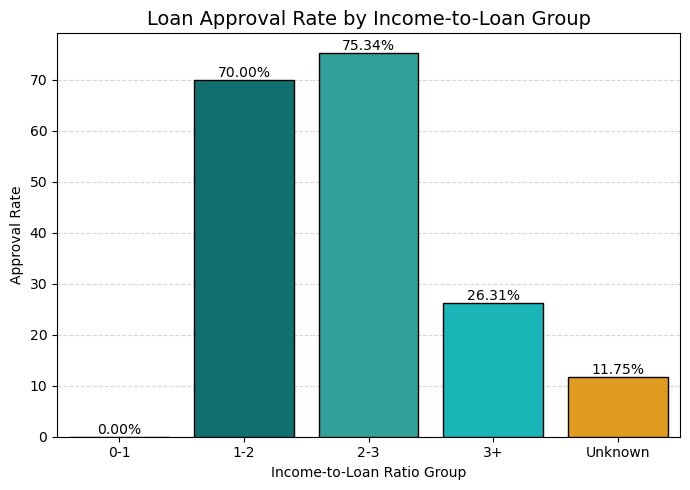

In [45]:
# Define order of ratio groups
ratio_groups=['0-1','1-2','2-3','3+','Unknown']

# Reindex data to maintain correct order
approval_by_ratio=approval_by_ratio.reindex(ratio_groups,fill_value=0)

# Create figure
plt.figure(figsize=(7,5))

# Plot bar chart
sns.barplot(
    x=approval_by_ratio.index,
    y=approval_by_ratio.values,
    hue=approval_by_ratio.index,
    palette=['#2E86c1','#008080','#20B2AA','#00CED1','#FFA500'],
    edgecolor='black',
    legend=False,
    errorbar=None
)

# Add title and labels
plt.title('Loan Approval Rate by Income-to-Loan Group', fontsize=14)
plt.xlabel('Income-to-Loan Ratio Group')
plt.ylabel('Approval Rate')

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels
for i,v in enumerate(approval_by_ratio.values):
    plt.text(i,v+0.5,f"{v:.2f}%",ha='center',fontsize=10)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi4_income_to_loan.png", dpi=300, bbox_inches='tight')

# Display chart
plt.show()

**Interpretation**:
- Loan approval rates vary significantly across income-to-loan ratio groups.
- Applicants with a ratio of **1–2** have a **70%** approval rate, while those with a ratio of **2–3** have the highest approval at **75.34%**.
- In contrast, applicants in the **3+** group, despite being the largest group, have a much lower approval rate of **26.31%** and about **11.75** of applicants fall into the Unknown category,representing unclassified cases.
- This suggests that banks or loan providers are more likely to approve loans when the applicant’s income is reasonably proportionate to the requested loan, while approval decreases when the income far exceeds the loan amount.

### Loan Approval by Education level(Bar Chart)

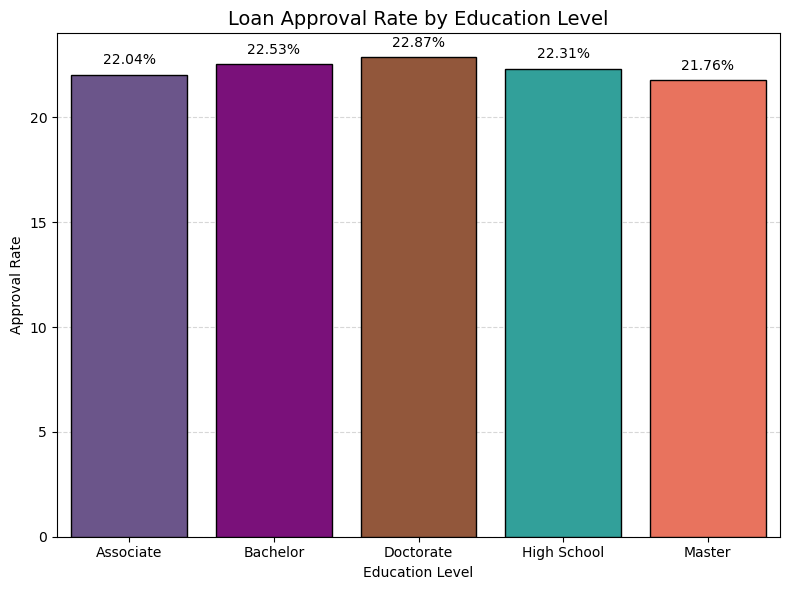

In [68]:
# Create figure
plt.figure(figsize=(8,6))

# Plot bar chart for education levels
sns.barplot(
    x=approval_by_education.index,
    y=approval_by_education.values,
    hue=approval_by_education.index,
    palette=['#6A4C93','#8B008B','#A0522D','#20B2AA','#FF6347'],
    edgecolor='black',
    errorbar=None
)

# Add title and labels
plt.title('Loan Approval Rate by Education Level', fontsize=14)
plt.xlabel('Education Level')
plt.ylabel('Approval Rate')

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels
for i,v in enumerate(approval_by_education.values):
    plt.text(i,v+0.5,f"{v:.2f}%",ha='center',fontsize=10)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi5_education.png", dpi=300, bbox_inches='tight')

# Show chart
plt.show()

**Interpretation**:
- Loan approval rates are very similar across all education levels, ranging from **21.76%** to **22.87%**, showing only slight differences.
- Applicants with a **Doctorate** (22.87%) and **Bachelor’s** degree (22.53%) have slightly higher approval rates, while those with a **Master’s** degree (21.76%) show the lowest.
- Overall, education level does not appear to be a major factor in loan approval — banks or loan providers seem to approve applicants regardless of educational background.

### Loan Approval by Employment Experience(Bar Chart)

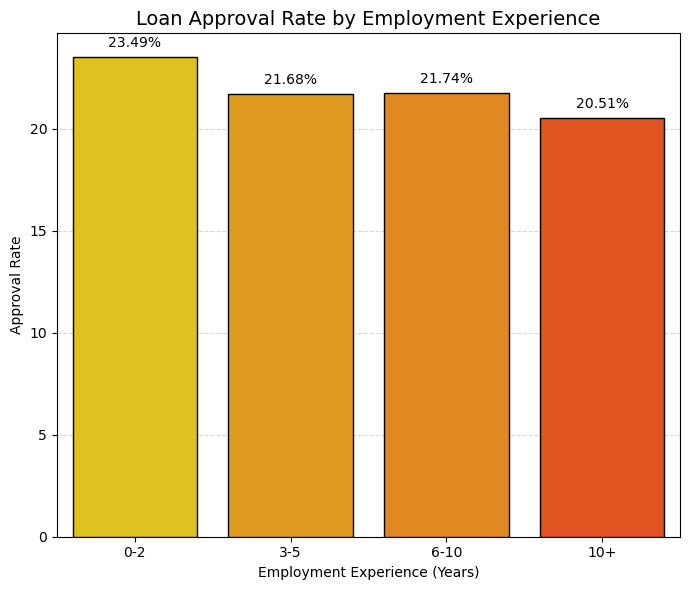

In [69]:
# Create figure
plt.figure(figsize=(7,6))

# Plot bar chart for employment experience
sns.barplot(
    x=approval_by_exp.index,
    y=approval_by_exp.values,
    hue=approval_by_exp.index,
    palette=['#FFD700','#FFA500','#FF8C00','#FF4500'],
    edgecolor='black',
    errorbar=None
)

# Add title and labels
plt.title('Loan Approval Rate by Employment Experience', fontsize=14)
plt.xlabel('Employment Experience (Years)')
plt.ylabel('Approval Rate')

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels
for i,v in enumerate(approval_by_exp.values):
    plt.text(i,v+0.5,f"{v:.2f}%",ha='center',fontsize=10)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi6_emp_exp.png", dpi=300, bbox_inches='tight')

# Display chart
plt.show()

**Interpretation**:
- Loan approval rates slightly decrease as employment experience increases.
- Applicants with **0–2** years of experience have the highest approval rate at **23.49%**, while those with **10+** years have the lowest at **20.51%**.
- Overall, the differences are small, suggesting that banks or loan providers do not heavily weigh employment experience when approving loans, although very new employees (0–2 years) seem to have a slightly higher chance of approval.

### Loan Approval by Home Ownership(Bar Chart)

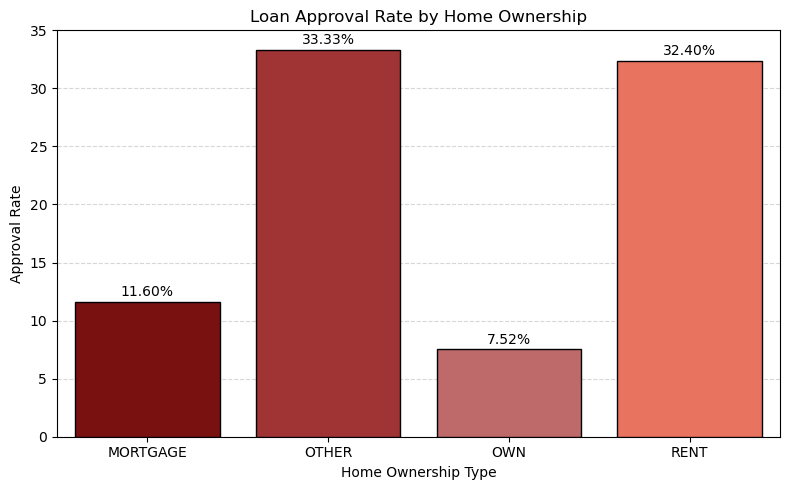

In [70]:
# Create figure
plt.figure(figsize=(8,5))

# Plot bar chart for home ownership
sns.barplot(
    x=approval_by_home.index,
    y=approval_by_home.values,
    hue=approval_by_home.index,
    palette=['#8B0000','#B22222','#CD5C5C','#FF6347'],
    edgecolor='black',
    errorbar=None
)

# Add title and labels
plt.title('Loan Approval Rate by Home Ownership')
plt.xlabel('Home Ownership Type')
plt.ylabel('Approval Rate')

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels
for i,v in enumerate(approval_by_home.values):
    plt.text(i,v+0.5,f"{v:.2f}%",ha='center',fontsize=10)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi7_home_ownership.png", dpi=300, bbox_inches='tight')

# Display chart
plt.show()

**Interpretation**:
- Applicants who **Rent** (32.40%) or are classified as **Other** (33.33%) have significantly higher approval rates compared to **Mortage** (11.60%) or **Own** homes
 (7.52%).
- Although the **Other** category shows a 33.33% approval rate,it likely contains very few applicants,so that value may not be statistically meaningful.
- Overall,**Renters** appear to have a stronger approval rate,while **Own** or existing **Mortages** might signal ongoing financial commitments.

### Loan Approval  by Previous Loan Defaults(Bar Chart)

<Figure size 800x500 with 0 Axes>

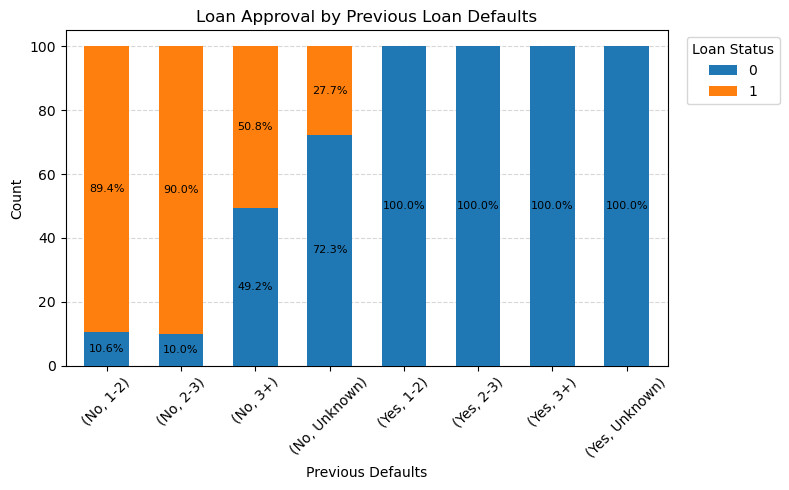

In [27]:
#create figure
plt.figure(figsize=(8,5))

# Plot bar chart for previous loan defaults
ax = approval_crosstab_by_default_income.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),
    width=0.6
)

# Add title and labels
plt.title('Loan Approval by Previous Loan Defaults')
plt.xlabel('Previous Defaults')
plt.ylabel('Count')

# Rotate x labels for readability
plt.xticks(rotation=45)

#Add legend
plt.legend(title='Loan Status', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5,zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels
for container in ax.containers:
     for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{height:.1f}%',
                ha='center', va='center', fontsize=8
            )

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi8_previous_defaults_crosstab.png", dpi=300, bbox_inches='tight')

# Display chart
plt.show()

**Interpretation**:
- Applicants with previous loan defaults have a **0%** approval rate across all income-to-loan groups, confirming it as the strongest rejection factor.
- For applicants with **NO** previous defaults, approval is high in lower ratio groups (1–2, 2–3).but drops significantly in the 3+ group, indicating higher risk at extreme ratios.
- The higher rejection in the **3+** category is also influenced by a larger sample size, but still suggests that very high ratios reduce approval chances.
- The Unknown group shos lower approval(**27.68%**) even without defaults,highlighting unclassified cases.overall,both previous and extreme income-to-loan ratios strongly influence loan approval decisions.

### Loan Approval Rate by Loan Intent(Bar Chart)

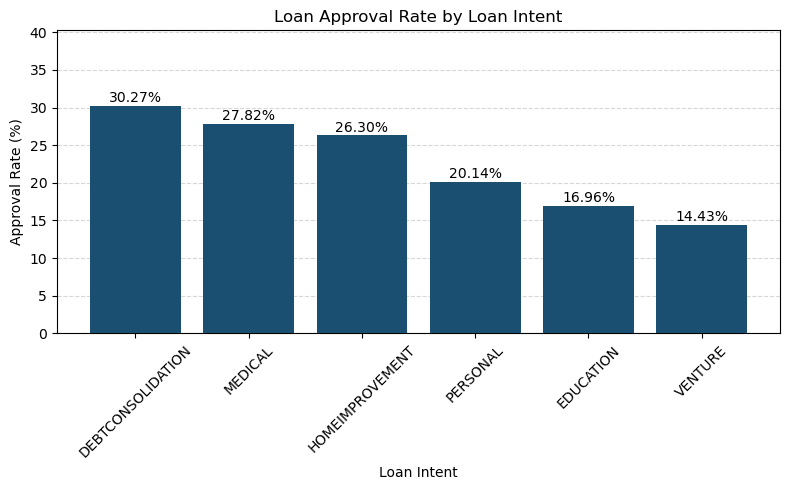

In [72]:
# Create figure
plt.figure(figsize=(8,5))

# Plot bar chart
bars=plt.bar(approval_by_intent['loan_intent'],
             approval_by_intent['ApprovalRate'],
             color='#1B4F72')

# Add title and labels
plt.title('Loan Approval Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Approval Rate (%)')

# Rotate x labels for readability
plt.xticks(rotation=45)

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{height:.2f}%',
             ha='center',
             fontsize=10)

# Adjust y-axis range
plt.ylim(0, max(approval_by_intent['ApprovalRate']) + 10)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi11_approval_by_intent.png", dpi=300, bbox_inches='tight')

# Show chart
plt.show()

**Interpretation**:
- Loan approval rates vary significantly depending on the applicant’s loan purpose.
- Applicants seeking **Debt Consolidation** (30.27%), **Medical** (27.82%), and **Home Improvement** (26.30%) loans have the highest approval rates. - -- These loans are often considered essential or responsible uses of credit.
- In contrast, **Personal** (20.14%), **Education** (16.96%) and **Venture** (14.43%) loans have lower approval rates, possibly because banks perceive them as less urgent or higher risk.
- Overall, the loan purpose plays an important role in approval decisions, with essential or structured needs being favored by lenders.

### Average Loan Amount by Loan intent(Bar Chart)

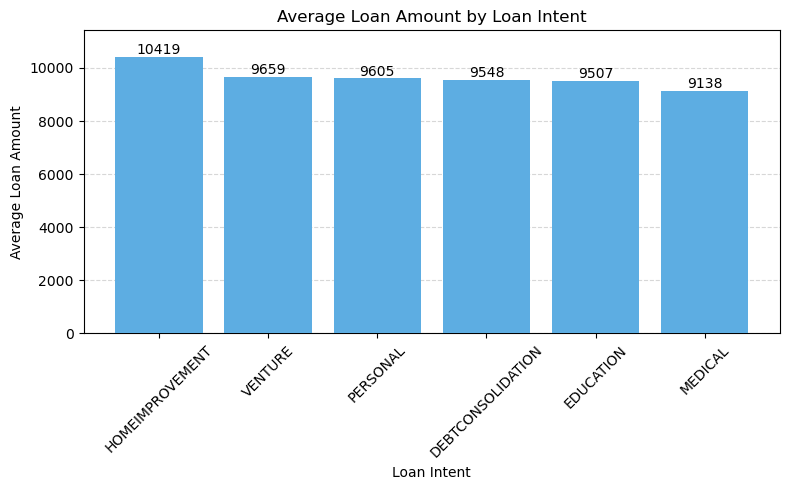

In [74]:
# Create figure
plt.figure(figsize=(8,5))

# Plot bar chart for average loan amount
bars=plt.bar(avg_loan_by_intent['loan_intent'],
             avg_loan_by_intent['Avg_loan_amount'],
             color='#5DADE2')

# Add title and labels
plt.title('Average Loan Amount by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Average Loan Amount')

# Rotate x labels
plt.xticks(rotation=45)

# Add background grid
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Ensure bars appear above grid
for patch in plt.gca().patches:
    patch.set_zorder(3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 100,
             f'{height:.0f}',
             ha='center',
             fontsize=10)

# Adjust y-axis range
plt.ylim(0, max(avg_loan_by_intent['Avg_loan_amount']) + 1000)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("kpi9_avg_loan_by_intent.png", dpi=300, bbox_inches='tight')

# Show chart
plt.show()

**Interpretation**:
- **Home Improvement** loans have the highest average amount (₹10,419), followed by **Venture**, **Personal** and **Debt Consolidation**.
- **Education** and **Medical** loans have the lowest averages.
- This shows that banks approve slightly larger loans for investment or business purposes compared to essential or structured needs.

## 7.Key Insights Summary

- Overall Approval: Only 22.23% of applicants were approved, showing strict bank screening.
- Gender: Approval rates are nearly identical for Males (22.21%) and Females (22.25%), indicating gender neutrality.
- Age Group: Older applicants (51–60: 26%, 60+: 25.35%) have higher approval rates, suggesting financial stability matters.
- Income-to-Loan Ratio: Applicants with a ratio of 2–3 have the highest approval (75.34%), while 3+ have lower (26.31%), showing balanced ratios are preferred.
- Education Level: Minimal impact on approval, with rates ranging from 21.76%–22.87%.
- Employment Experience: Slight decrease in approval from 0–2 years (23.49%) to 10+ years (20.51%).
- Home Ownership: Renters have higher approval rates (32.4%) than those with a mortgage or own homes, while Other is high but based on very few applicants.
- Previous Defaults: Applicants with prior defaults have near-zero approval across all groups, while even among those with no defaults, approval drops at very high income-to-loan ratios, confirming defaults as the strongest risk factor and ratios as a secondary influence.
- Loan Purpose: Debt Consolidation (30.27%) and Medical (27.82%) loans are approved most often; Education (16.96%) and Venture (14.43%) are least.
- Average Loan Amount: Home Improvement loans have the highest average (₹10,419), while Education and Medical loans are lowest.
- Key Drivers: Previous defaults, loan purpose and reasonable income-to-loan ratios are the main factors affecting approvals.

## 8.Conclusion

This project provided hands-on experience in analyzing real-world loan data to identify factors influencing loan approvals. Key insights revealed that previous defaults, loan purpose and income-to-loan ratio are the primary drivers of approval, while demographics such as age, gender, education, and employment experience have a smaller effect. Additionally, home ownership status showed moderate impact, with renters having higher approval rates than those with mortgages or owned homes. Although one might expect higher approval rate of ~30%,the dataset shos only 22.23% approvals,indicating stricker bank screening and careful risk assessment.The project strengthened my understanding of data cleaning, aggregation, visualization, and storytelling with Python, preparing me to extract meaningful insights in future data analysis projects. Minor limitations, such as very small sample sizes in the “Other” home ownership category, may affect statistical significance for that group.